# 02 - Train YOLOv10s on DataPCB Final Clean 6-Class Dataset

This notebook follows the previous working `7_gk-yolov11m.ipynb` style, but uses the new final clean dataset and YOLOv10s.

## 1. Install and imports

In [1]:
%pip -q install ultralytics==8.4.30

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from ultralytics import YOLO

from pathlib import Path
import random
import shutil
import json
import yaml
from collections import Counter

import cv2
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = Path("/kaggle/working")

# New final clean dataset. The notebook supports both possible Kaggle dataset owners.
POSSIBLE_SOURCE_ROOTS = [
    Path("/kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/pcb-merged/DataPCB_Final_Clean_6cls"),
]

SOURCE_DATASET_ROOT = None
for p in POSSIBLE_SOURCE_ROOTS:
    print("Checking:", p, "| exists:", p.exists())
    if p.exists():
        SOURCE_DATASET_ROOT = p
        break

assert SOURCE_DATASET_ROOT is not None, "Could not find DataPCB_Final_Clean_6cls in expected Kaggle input paths."

DATA_DIR = ROOT / "DataPCB_Final_Clean_6cls"
DATA_YAML = DATA_DIR / "data.yaml"

PROJECT = "PCB_Baseline"

CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]

print("SOURCE_DATASET_ROOT:", SOURCE_DATASET_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_YAML:", DATA_YAML)


TRAIN_NAME = "yolov10s_final_clean_6cls_e50"
TEST_NAME = "yolov10s_final_clean_6cls_test_eval"
PRED_NAME = "yolov10s_final_clean_6cls_test_predictions"

TRAIN_DIR = ROOT / "runs" / "detect" / PROJECT / TRAIN_NAME
TEST_DIR = ROOT / "runs" / "detect" / PROJECT / TEST_NAME
PRED_DIR = ROOT / "runs" / "detect" / PROJECT / PRED_NAME

BEST_PT = TRAIN_DIR / "weights" / "best.pt"
LAST_PT = TRAIN_DIR / "weights" / "last.pt"
RESULTS_CSV = TRAIN_DIR / "results.csv"

REPORT_DIR = ROOT / "yolov10s_reports"
ARTIFACT_DIR = ROOT / "yolov10s_artifacts"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Checking: /kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls | exists: False
Checking: /kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls | exists: True
SOURCE_DATASET_ROOT: /kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls
DATA_DIR: /kaggle/working/DataPCB_Final_Clean_6cls
DATA_YAML: /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml


## 2. Copy dataset to `/kaggle/working`

In [3]:
# Copy dataset to /kaggle/working to avoid read-only cache warnings from /kaggle/input.
# This follows the previous working notebooks.
FORCE_RECOPY = False

if FORCE_RECOPY and DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

if DATA_DIR.exists():
    print("Dataset already exists in /kaggle/working:", DATA_DIR)
else:
    print("Copying dataset to /kaggle/working...")
    shutil.copytree(SOURCE_DATASET_ROOT, DATA_DIR)
    print("Copied:", DATA_DIR)

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    print(split, "| images:", img_dir.exists(), "| labels:", lbl_dir.exists())
    assert img_dir.exists(), f"Missing image dir: {img_dir}"
    assert lbl_dir.exists(), f"Missing label dir: {lbl_dir}"

Copying dataset to /kaggle/working...
Copied: /kaggle/working/DataPCB_Final_Clean_6cls
train | images: True | labels: True
valid | images: True | labels: True
test | images: True | labels: True


## 3. Rewrite data.yaml

In [4]:
# Rewrite data.yaml so it points to the writable /kaggle/working copy.
data_yaml = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(DATA_YAML.read_text())

path: /kaggle/working/DataPCB_Final_Clean_6cls
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- missing_hole
- mouse_bite
- open_circuit
- short
- spur
- spurious_copper



## 4. Utility functions

In [5]:
def show_image(path, title=None):
    path = Path(path)
    if path.exists():
        if title:
            print(title)
        display(Image(filename=str(path)))
    else:
        print(f"Missing: {path}")

def load_csv(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

def compute_f1(precision, recall):
    return 2 * (precision * recall) / (precision + recall + 1e-16)

def safe_best_or_last(best_pt, last_pt):
    if Path(best_pt).exists():
        return Path(best_pt)
    if Path(last_pt).exists():
        return Path(last_pt)
    raise FileNotFoundError(f"No best.pt or last.pt found. Checked: {best_pt}, {last_pt}")

def metric_summary_from_test(test_metrics, index_name):
    P = test_metrics.box.mp
    R = test_metrics.box.mr
    F1 = compute_f1(P, R)

    speed = test_metrics.speed
    inference_time = speed.get("inference", None)
    fps = 1000 / inference_time if inference_time and inference_time > 0 else None

    summary = pd.DataFrame([{
        "precision": P,
        "recall": R,
        "f1": F1,
        "mAP50": test_metrics.box.map50,
        "mAP50-95": test_metrics.box.map,
        "FPS": fps,
    }], index=[index_name])

    return summary

def per_class_map_from_test(test_metrics, class_names):
    rows = []

    maps = getattr(test_metrics.box, "maps", None)
    ap_class_index = getattr(test_metrics.box, "ap_class_index", None)

    if maps is None:
        return pd.DataFrame(rows)

    maps = list(maps)

    if ap_class_index is None:
        ap_class_index = list(range(len(maps)))
    else:
        ap_class_index = list(ap_class_index)

    for cls_idx, m in zip(ap_class_index, maps):
        cls_idx = int(cls_idx)
        rows.append({
            "class_id": cls_idx,
            "class_name": class_names[cls_idx] if 0 <= cls_idx < len(class_names) else str(cls_idx),
            "mAP50-95": float(m),
        })

    return pd.DataFrame(rows)

def quick_dataset_check(data_dir, class_names):
    img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
    summary_rows = []
    class_rows = []

    for split in ["train", "valid", "test"]:
        img_dir = data_dir / split / "images"
        lbl_dir = data_dir / split / "labels"

        images = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in img_exts])
        labels = sorted(lbl_dir.glob("*.txt"))

        c = Counter()
        total_boxes = 0

        for img in images:
            label_path = lbl_dir / f"{img.stem}.txt"
            if not label_path.exists():
                continue

            text = label_path.read_text().strip()
            if not text:
                continue

            for line in text.splitlines():
                parts = line.split()
                if len(parts) != 5:
                    continue
                cls_id = int(float(parts[0]))
                if 0 <= cls_id < len(class_names):
                    c[cls_id] += 1
                    total_boxes += 1

        summary_rows.append({
            "split": split,
            "num_images": len(images),
            "num_labels": len(labels),
            "total_boxes": total_boxes,
            "mean_boxes_per_image": total_boxes / max(1, len(images)),
        })

        for cls_id, cls_name in enumerate(class_names):
            class_rows.append({
                "split": split,
                "class_id": cls_id,
                "class_name": cls_name,
                "num_boxes": int(c.get(cls_id, 0)),
            })

    summary_df = pd.DataFrame(summary_rows)
    class_df = pd.DataFrame(class_rows)

    display(summary_df)
    display(class_df)

    assert summary_df.loc[summary_df["split"] == "train", "num_images"].iloc[0] > 0
    assert summary_df.loc[summary_df["split"] == "valid", "num_images"].iloc[0] > 0
    assert summary_df.loc[summary_df["split"] == "test", "num_images"].iloc[0] > 0

    return summary_df, class_df

def plot_results_csv(results_csv, loss_cols):
    df = load_csv(results_csv)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    for col, label, style in loss_cols:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linestyle=style, marker="o" if style == "-" else None, label=label)

    ax.set_title("Loss (Train vs Validation)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    metric_cols = [
        ("metrics/mAP50(B)", "mAP50"),
        ("metrics/mAP50-95(B)", "mAP50-95"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)", "Recall"),
    ]

    for col, label in metric_cols:
        if col in df.columns:
            ax.plot(df["epoch"], df[col], marker="o", label=label)

    ax.set_title("Validation Metrics")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

## 5. Quick dataset check

In [6]:
dataset_summary_df, class_distribution_df = quick_dataset_check(DATA_DIR, CLASS_NAMES)

REPORT_DIR.mkdir(parents=True, exist_ok=True)
dataset_summary_df.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)
class_distribution_df.to_csv(REPORT_DIR / "class_distribution.csv", index=False)

,split,num_images,num_labels,total_boxes,mean_boxes_per_image
0,train,6624,6624,19176,2.894928
1,valid,937,937,2712,2.894344
2,test,1887,1887,5352,2.836248


,split,class_id,class_name,num_boxes
0,train,0,missing_hole,3417
1,train,1,mouse_bite,3517
2,train,2,open_circuit,3007
3,train,3,short,2077
4,train,4,spur,4599
5,train,5,spurious_copper,2559
6,valid,0,missing_hole,478
7,valid,1,mouse_bite,460
8,valid,2,open_circuit,411
9,valid,3,short,307


## 6. Train YOLOv10s

In [7]:
model = YOLO("yolov10s.pt")

model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=32,
    device=[0, 1],
    workers=8,
    amp=True,
    seed=42,
    deterministic=True,
    patience=10,
    project=PROJECT,
    name=TRAIN_NAME,
    exist_ok=True,
    val=True,
    plots=True,
    save=True,
    save_period=5
)

New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/DataPCB_Final_Clean_6cls/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mi

## 7. Evaluate on test set

In [8]:
EVAL_PT = safe_best_or_last(BEST_PT, LAST_PT)
best_model = YOLO(str(EVAL_PT))

test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=32,
    device=[0, 1],
    project=PROJECT,
    name=TEST_NAME,
    exist_ok=True,
    plots=True,
    save_json=True
)

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLOv10s summary (fused): 106 layers, 7,220,322 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 746.6±174.6 MB/s, size: 29.4 KB)
val: Scanning /kaggle/working/DataPCB_Final_Clean_6cls/test/labels... 1887 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1887/1887 1.2Kit/s 1.6s
val: New cache created: /kaggle/working/DataPCB_Final_Clean_6cls/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 2.1it/s 28.7s
                   all       1887       5352      0.904      0.864       0.93      0.645
          missing_hole        541        986      0.945      0.956      0.987      0.852
            mouse_bite        658       1009      0.894      0.814        0.9      0.576
          open_circuit        563    

## 8. Result summary

,precision,recall,f1,mAP50,mAP50-95,FPS
YOLOv10s,0.904327,0.863967,0.883687,0.929797,0.645023,97.278278


,class_id,class_name,mAP50-95
0,0,missing_hole,0.852496
1,1,mouse_bite,0.576126
2,2,open_circuit,0.630667
3,3,short,0.607244
4,4,spur,0.491922
5,5,spurious_copper,0.711685


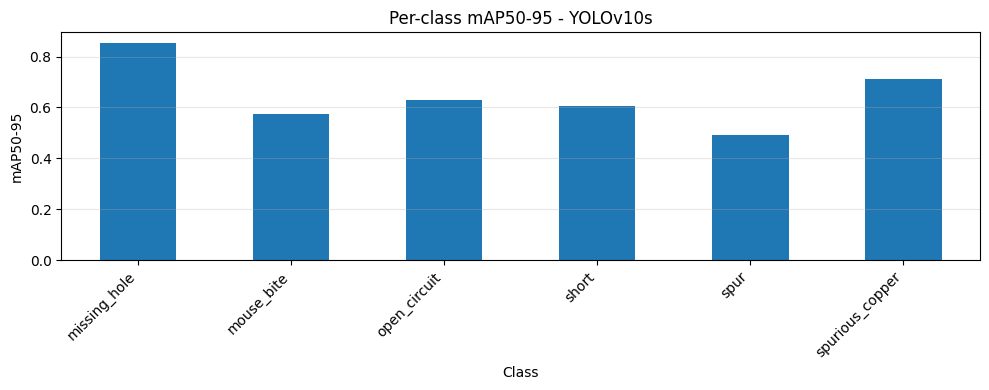

In [9]:
summary = metric_summary_from_test(test_metrics, "YOLOv10s")
per_class_df = per_class_map_from_test(test_metrics, CLASS_NAMES)

display(summary)
display(per_class_df)

summary.to_csv(REPORT_DIR / f"{TRAIN_NAME}_summary_metrics.csv")
per_class_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_per_class_map.csv", index=False)

if len(per_class_df) > 0:
    ax = per_class_df.set_index("class_name")["mAP50-95"].plot(kind="bar", figsize=(10, 4))
    ax.set_title("Per-class mAP50-95 - YOLOv10s")
    ax.set_xlabel("Class")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f"{TRAIN_NAME}_per_class_map.png", dpi=160)
    plt.show()

## 9. Show training artifacts

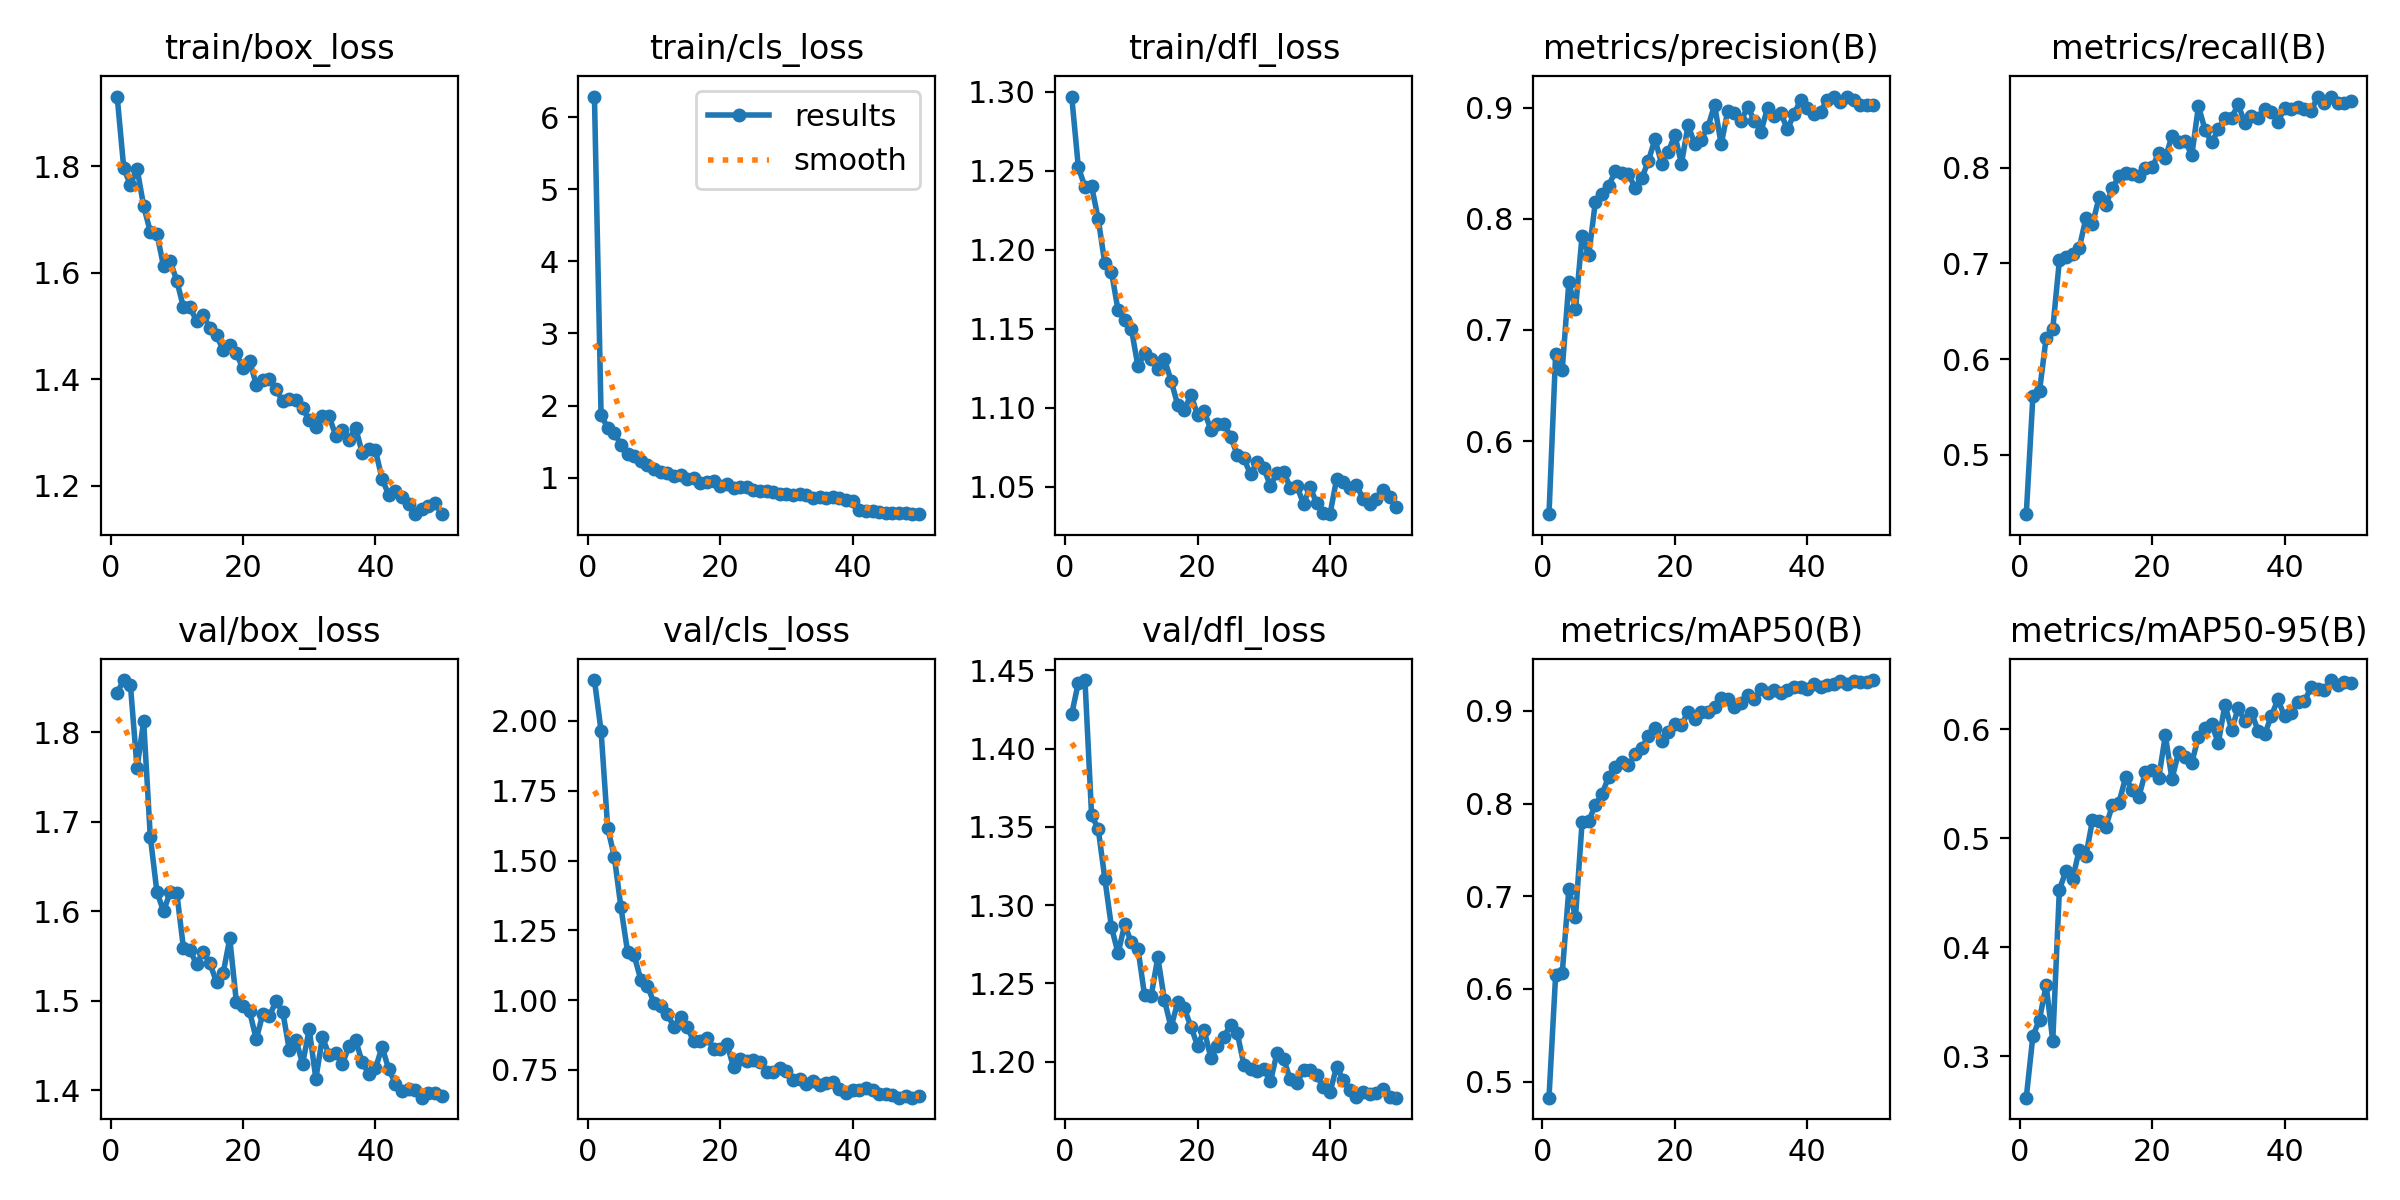

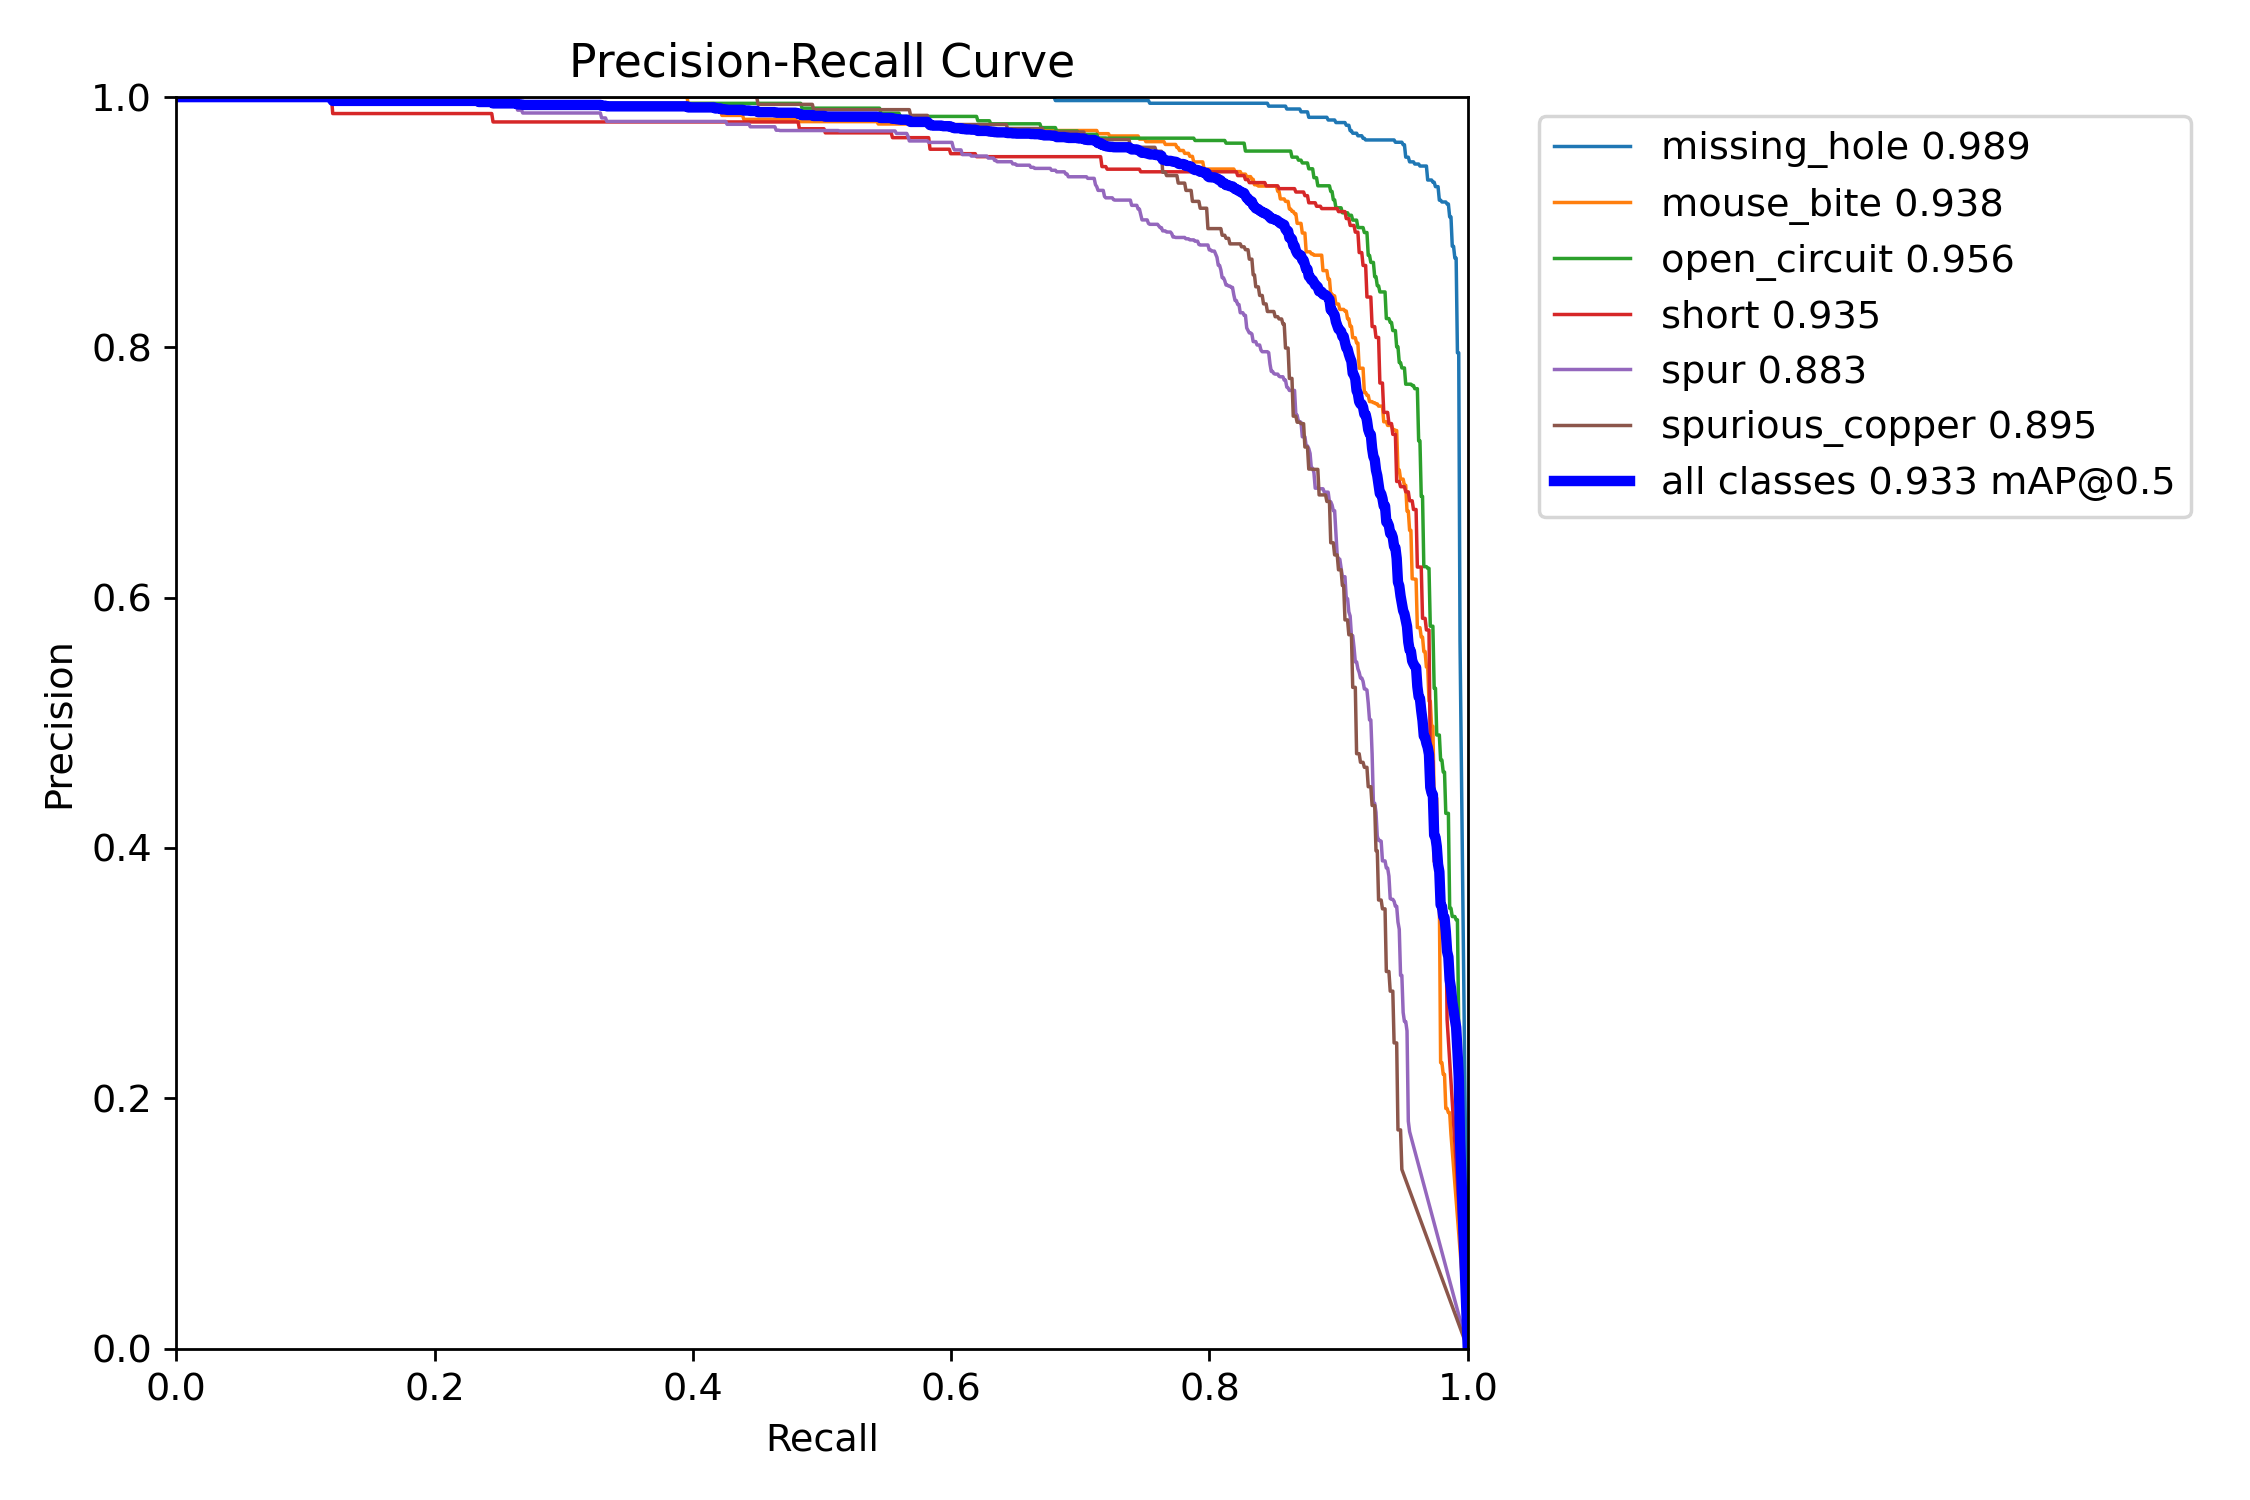

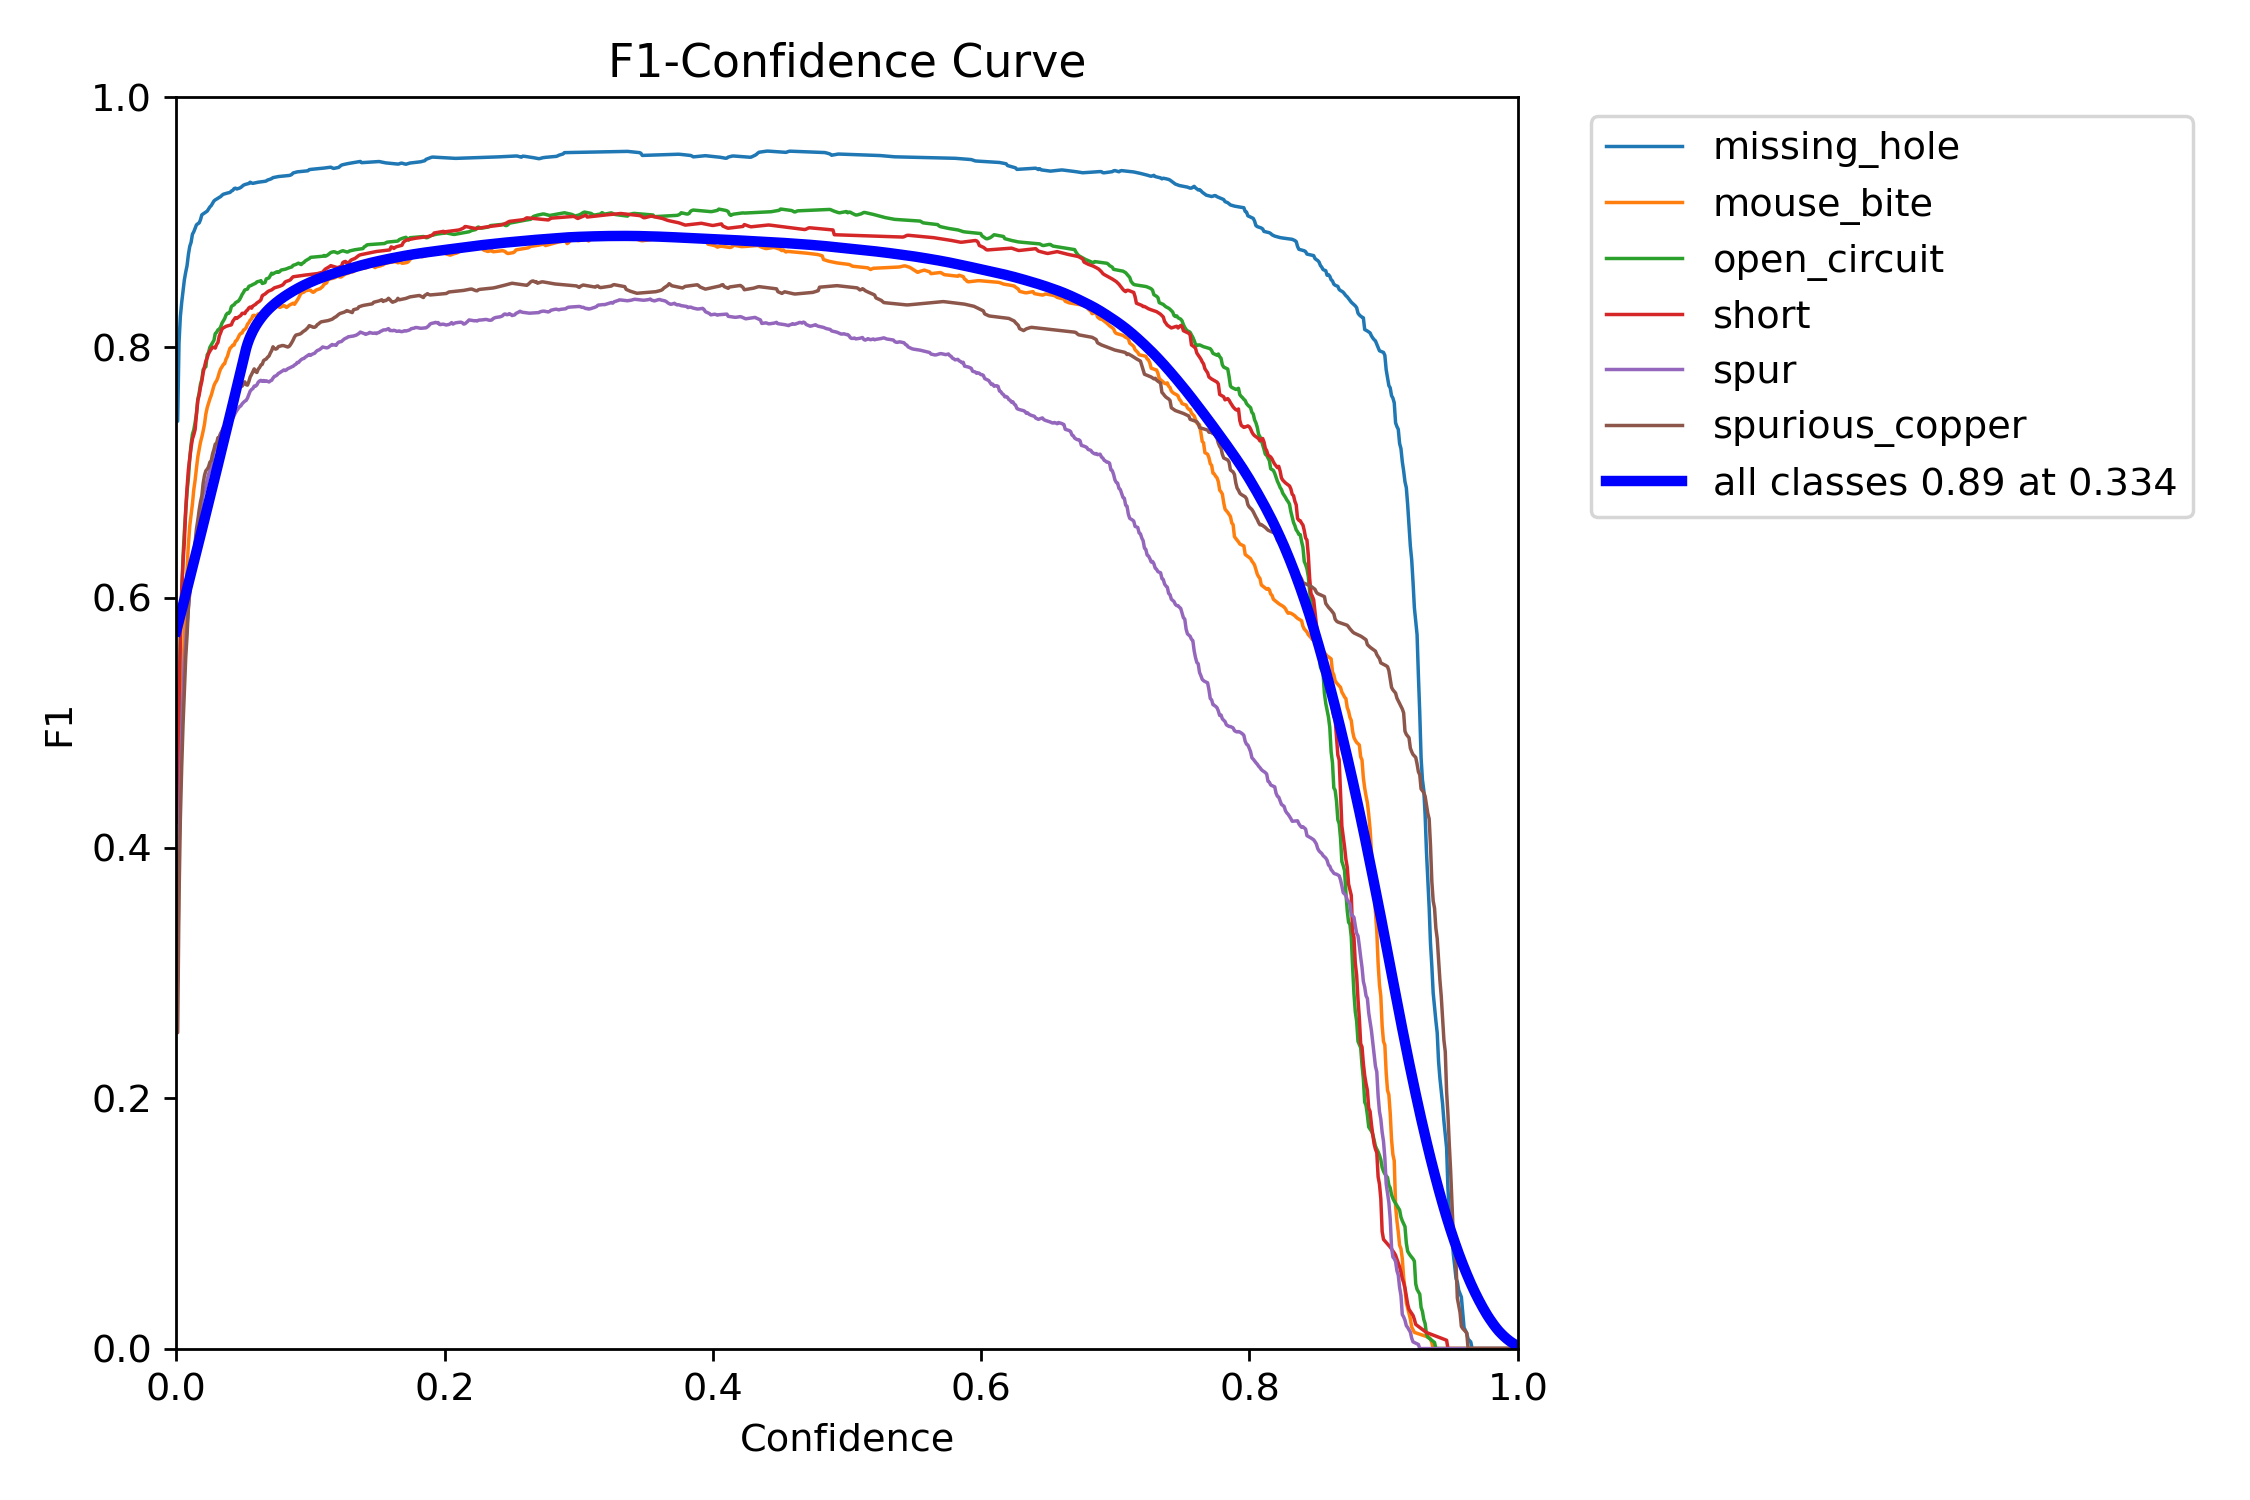

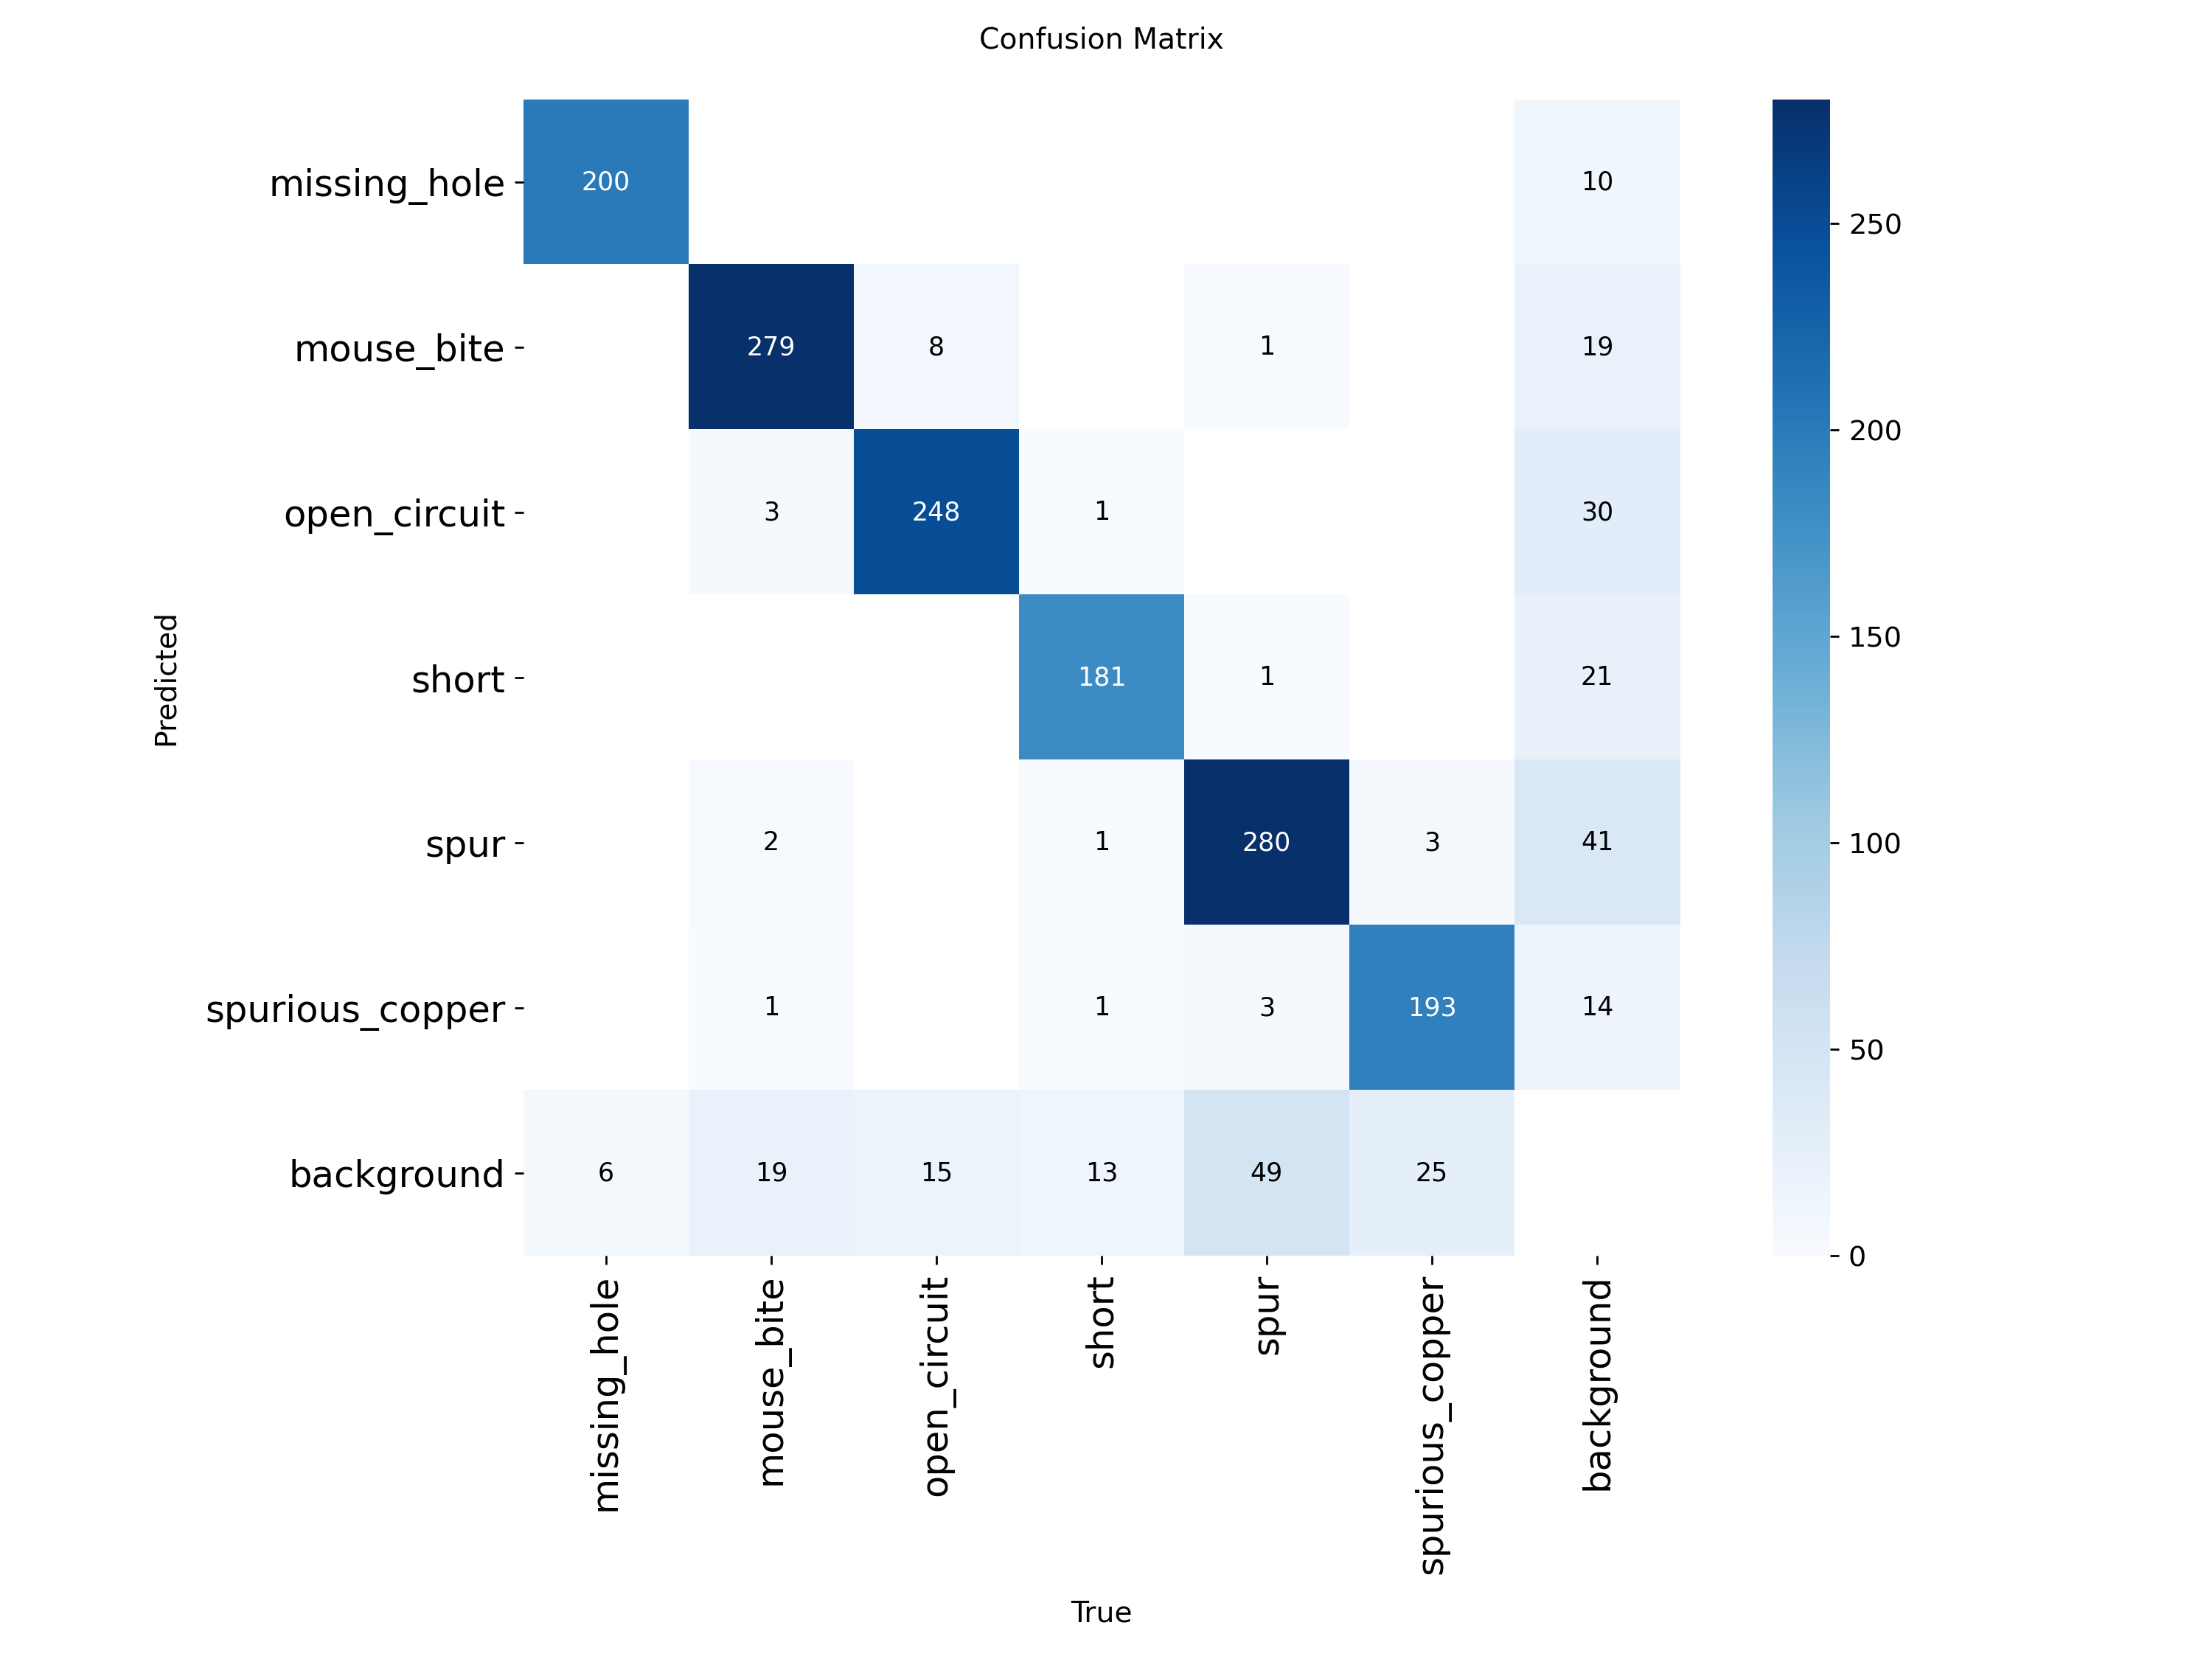

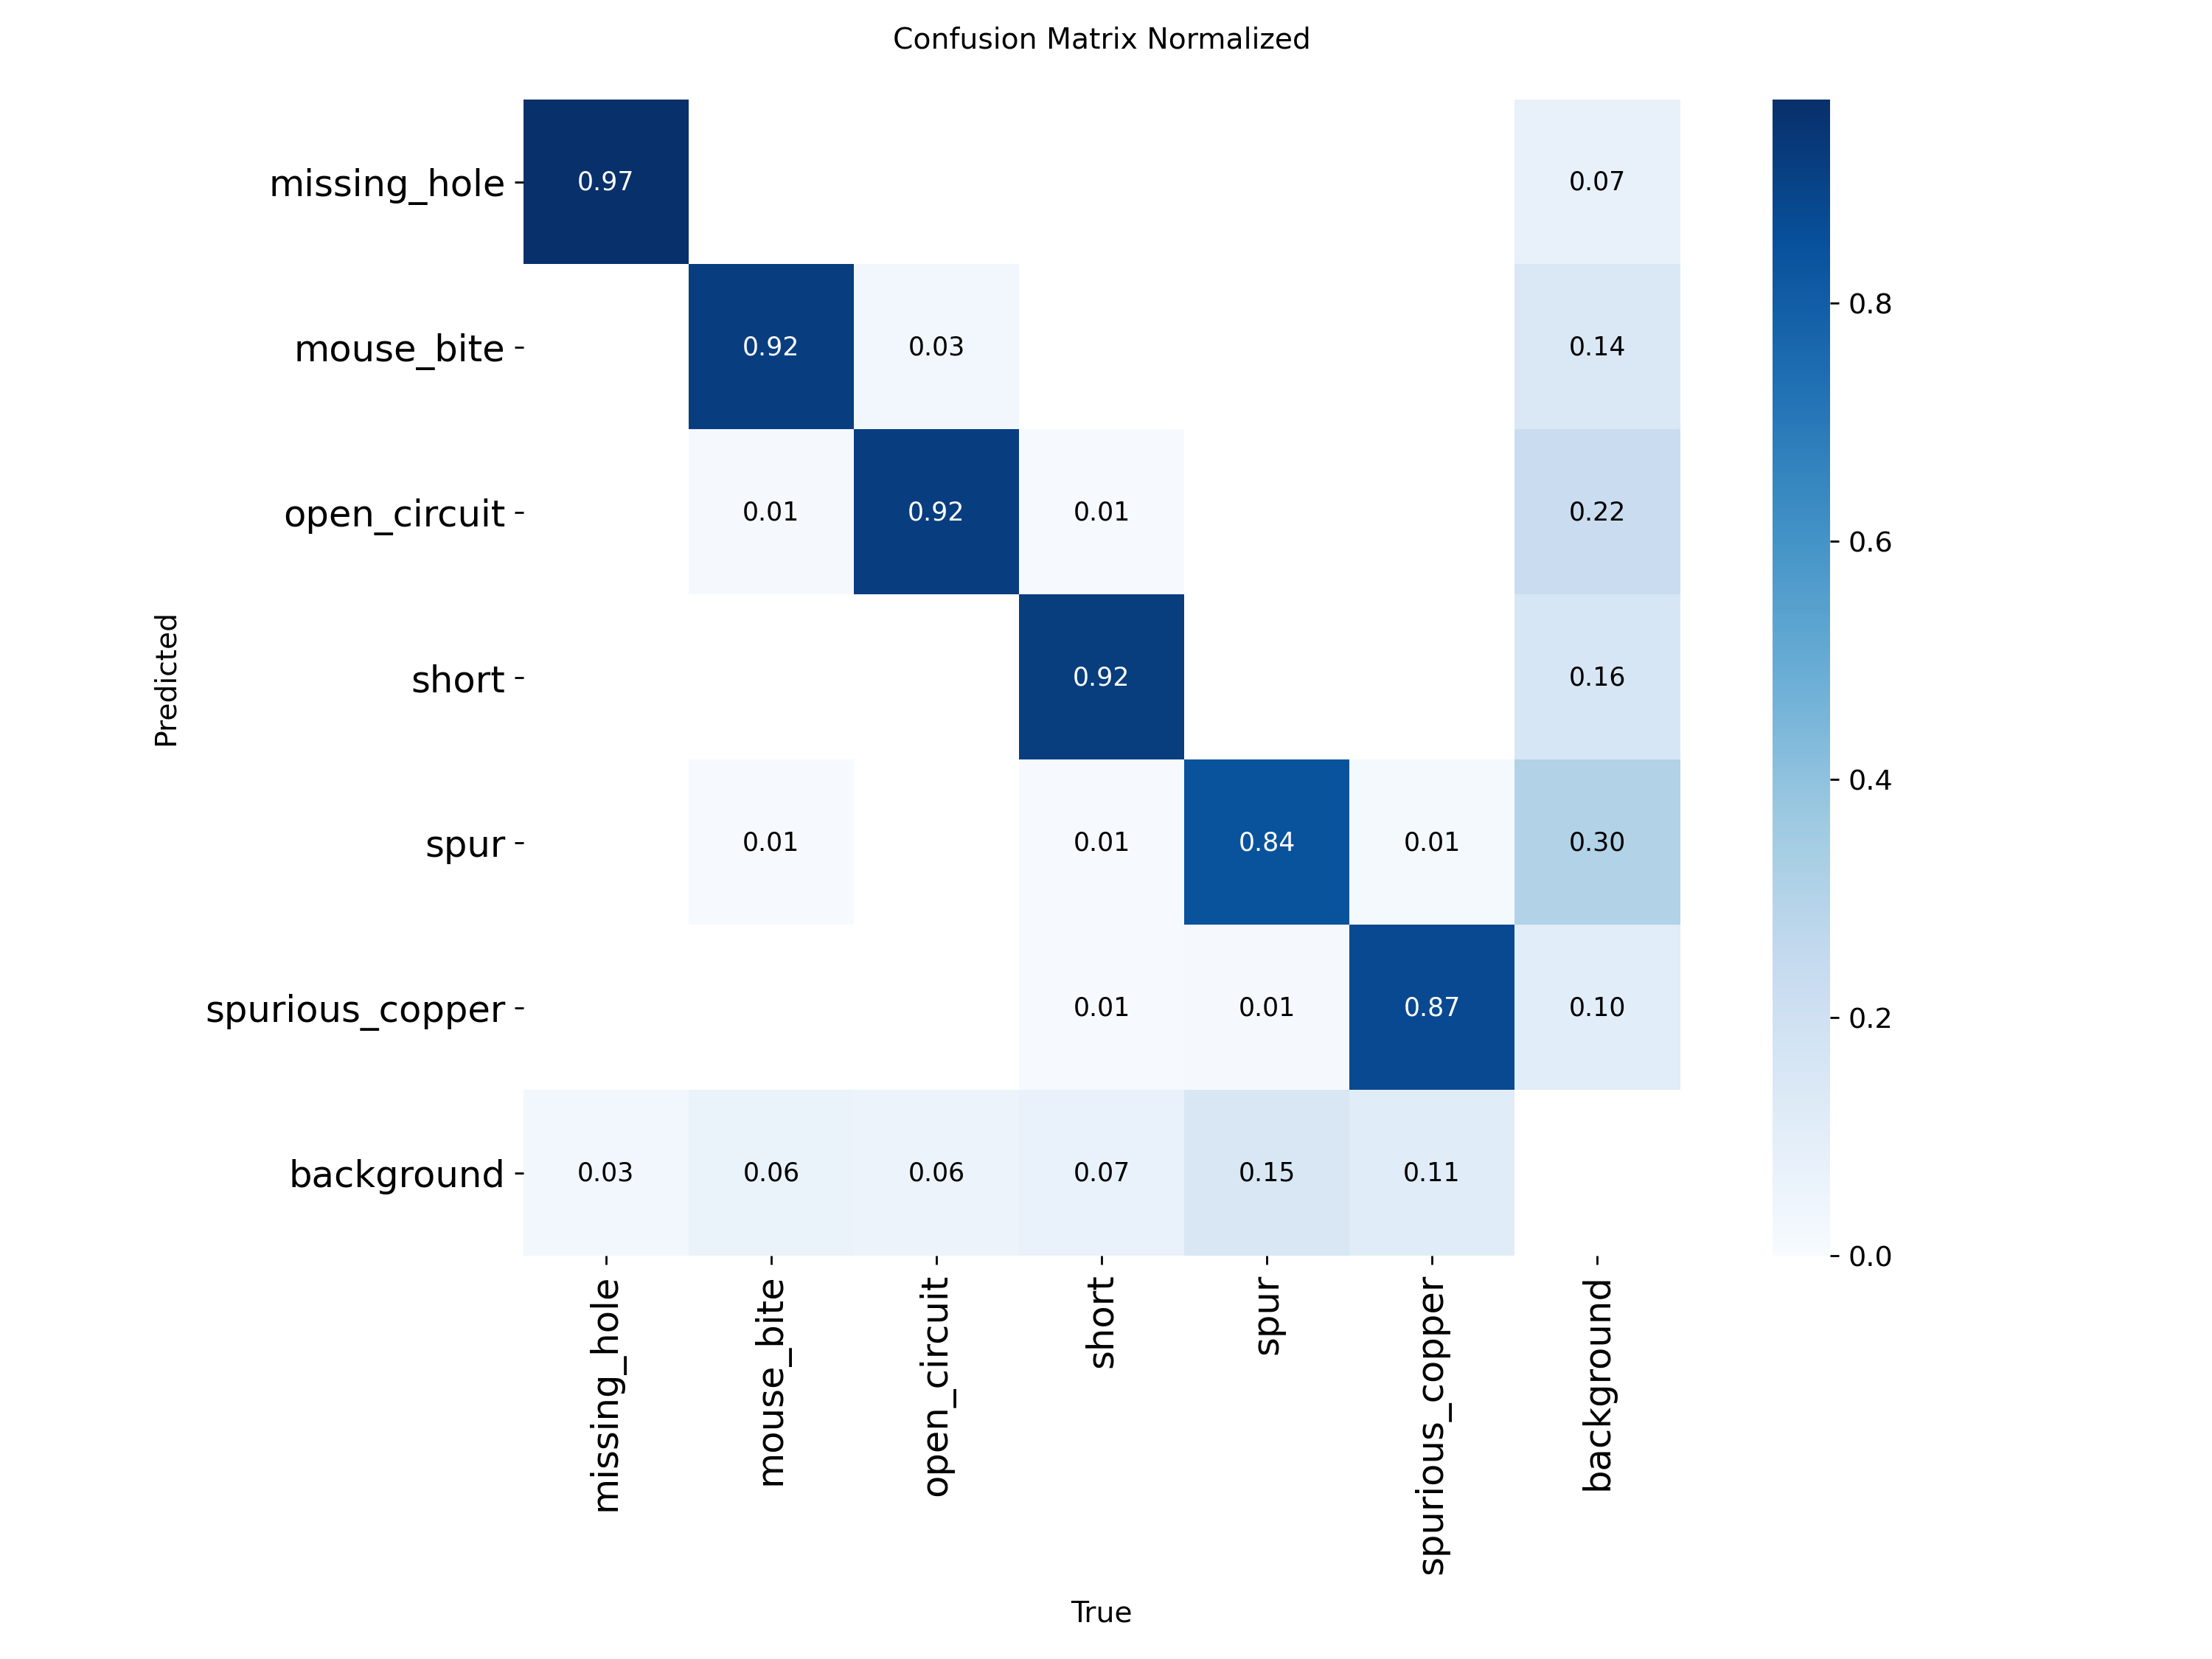

In [10]:
train_artifacts = [
    TRAIN_DIR / "results.png",
    TRAIN_DIR / "BoxPR_curve.png",
    TRAIN_DIR / "BoxF1_curve.png",
    TRAIN_DIR / "confusion_matrix.png",
    TRAIN_DIR / "confusion_matrix_normalized.png",
]

for p in train_artifacts:
    show_image(p)

## 10. Plot loss and metrics from results.csv

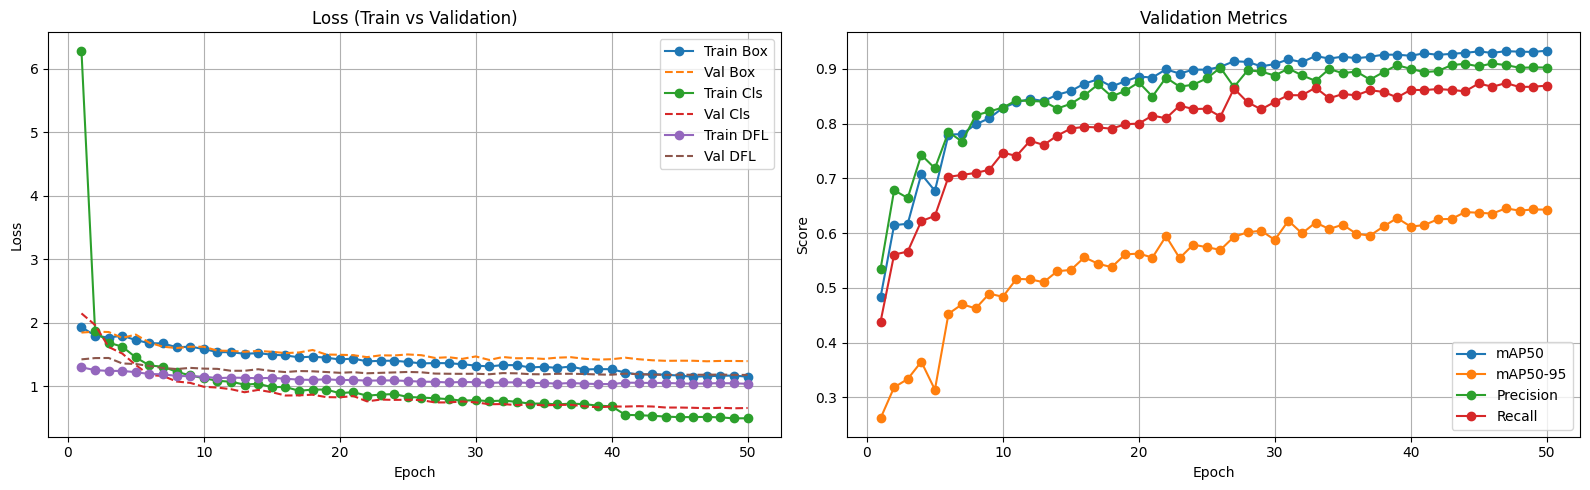

In [11]:
plot_results_csv(
    RESULTS_CSV,
    loss_cols=[
        ("train/box_loss", "Train Box", "-"),
        ("val/box_loss", "Val Box", "--"),
        ("train/cls_loss", "Train Cls", "-"),
        ("val/cls_loss", "Val Cls", "--"),
        ("train/dfl_loss", "Train DFL", "-"),
        ("val/dfl_loss", "Val DFL", "--"),
    ],
)

## 11. Confusion matrix on test

Normalized Confusion Matrix (Test)


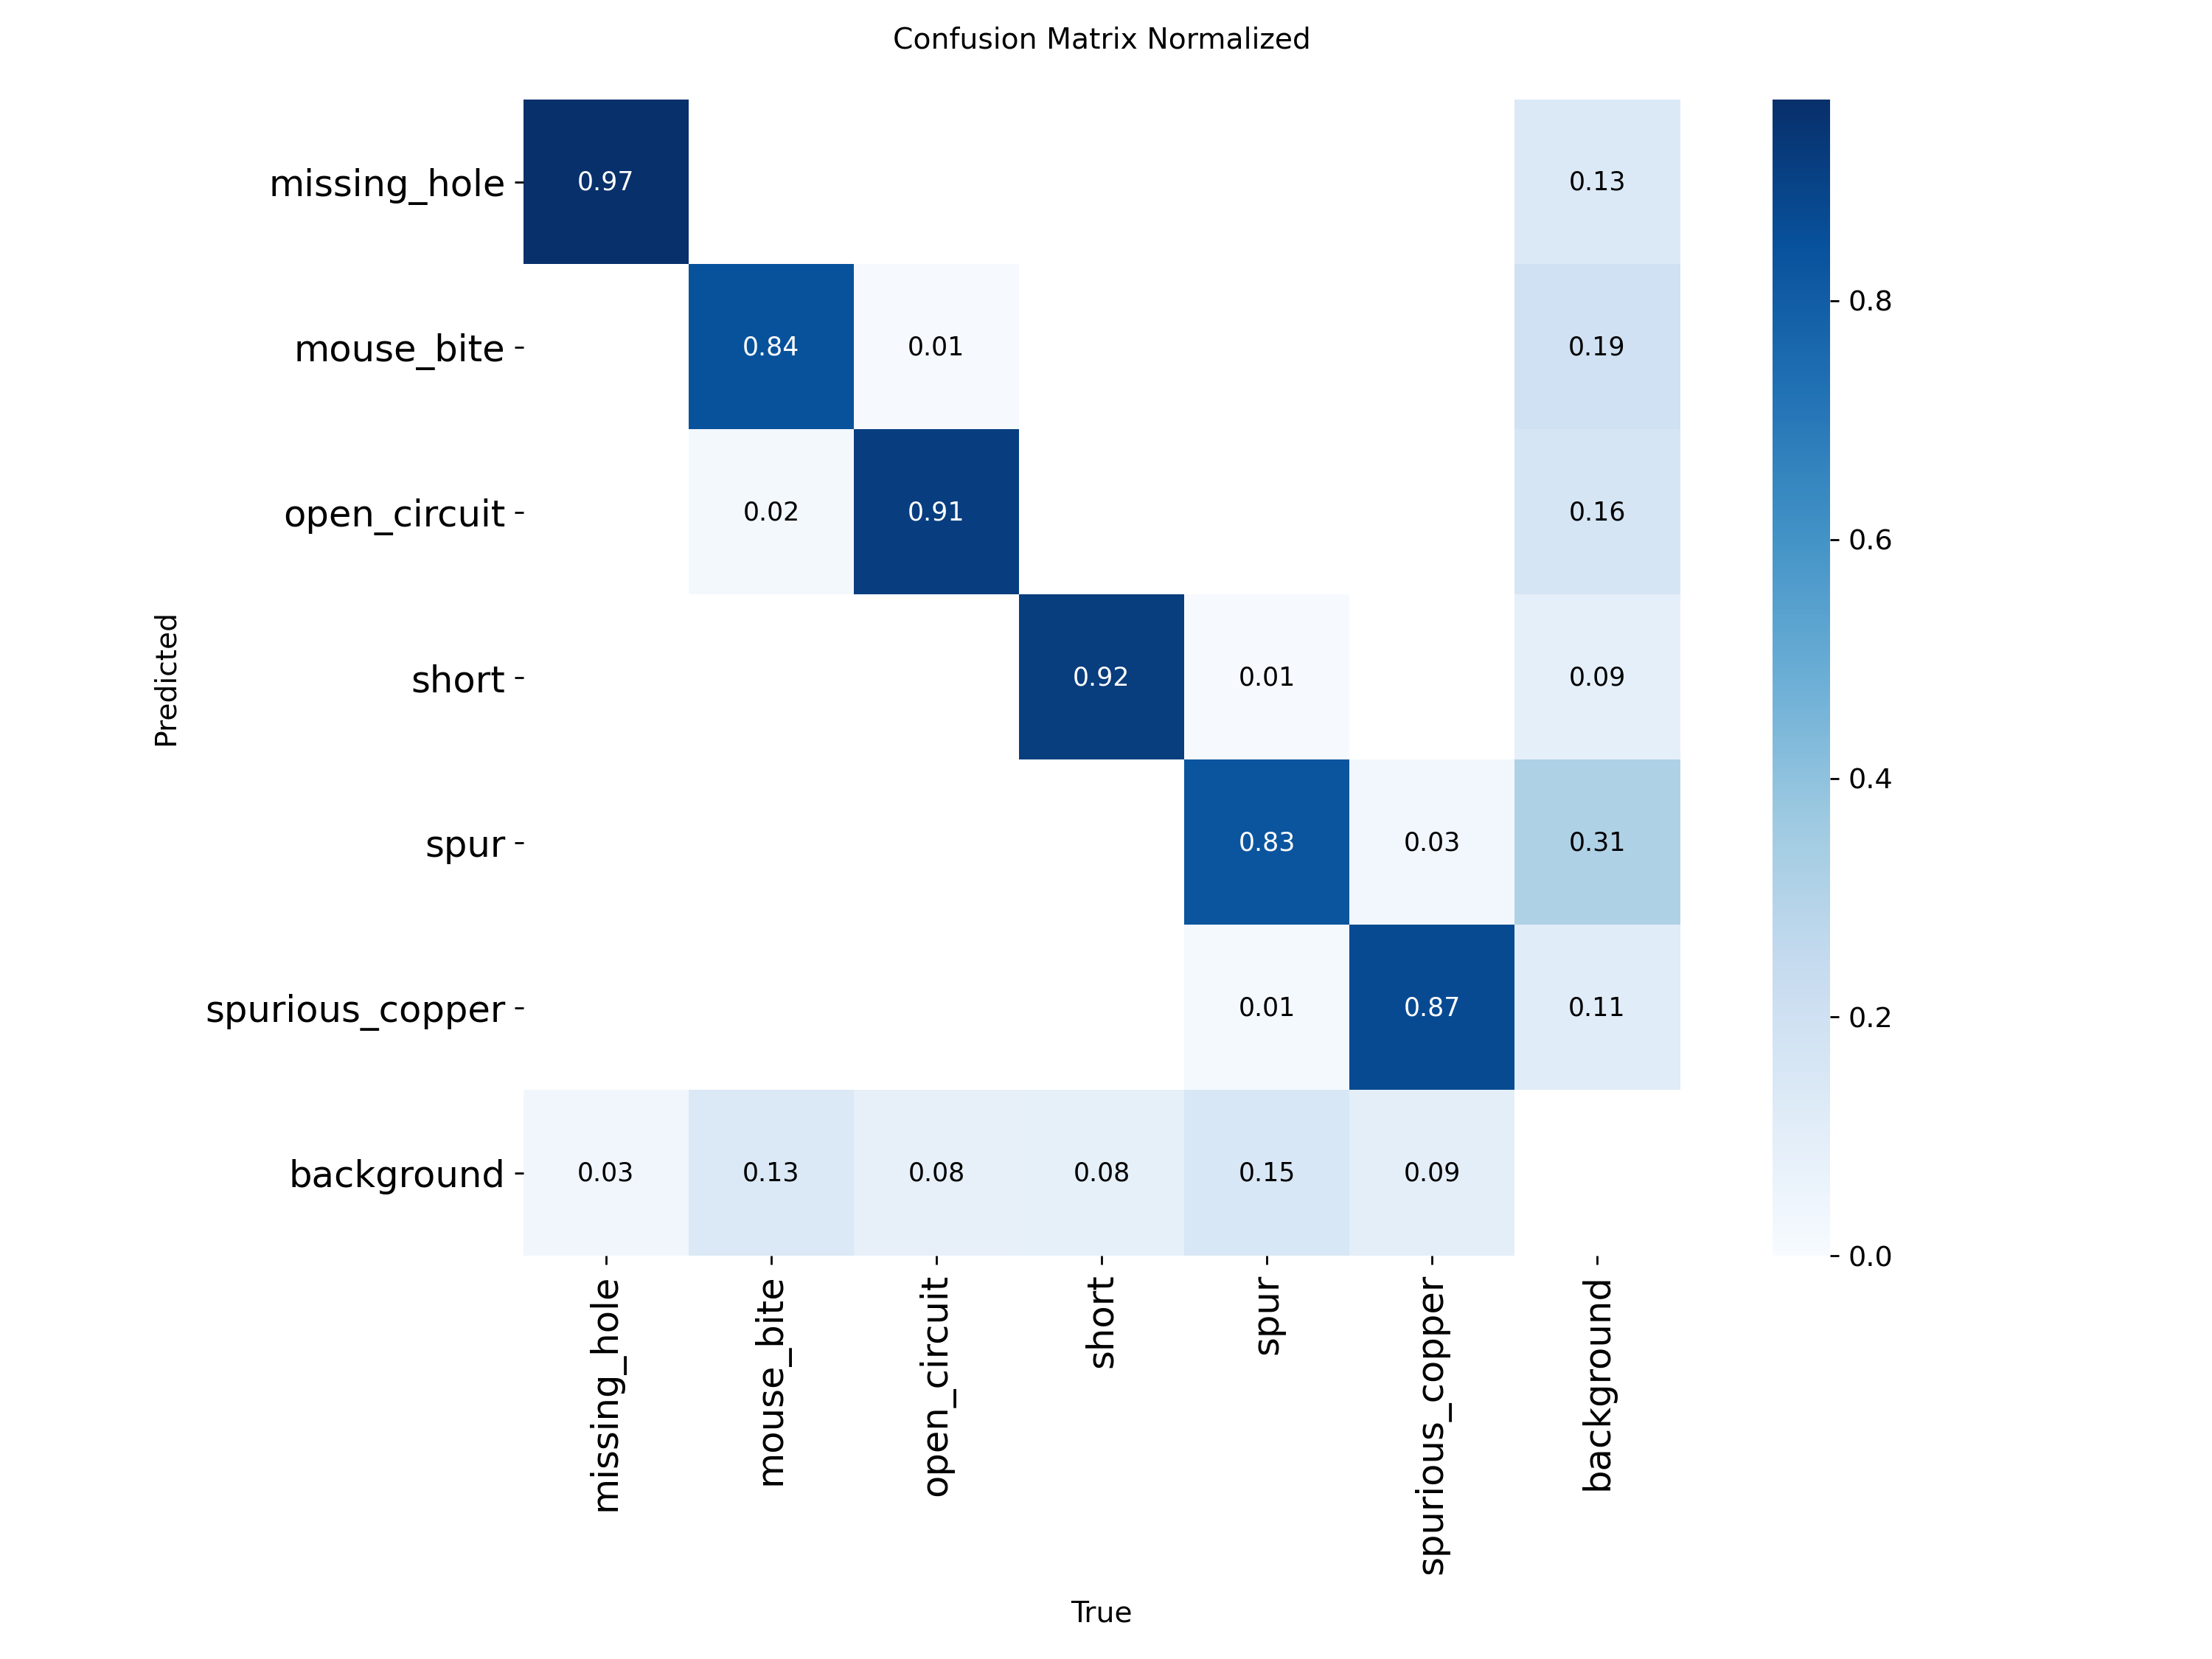

Confusion Matrix (Test)


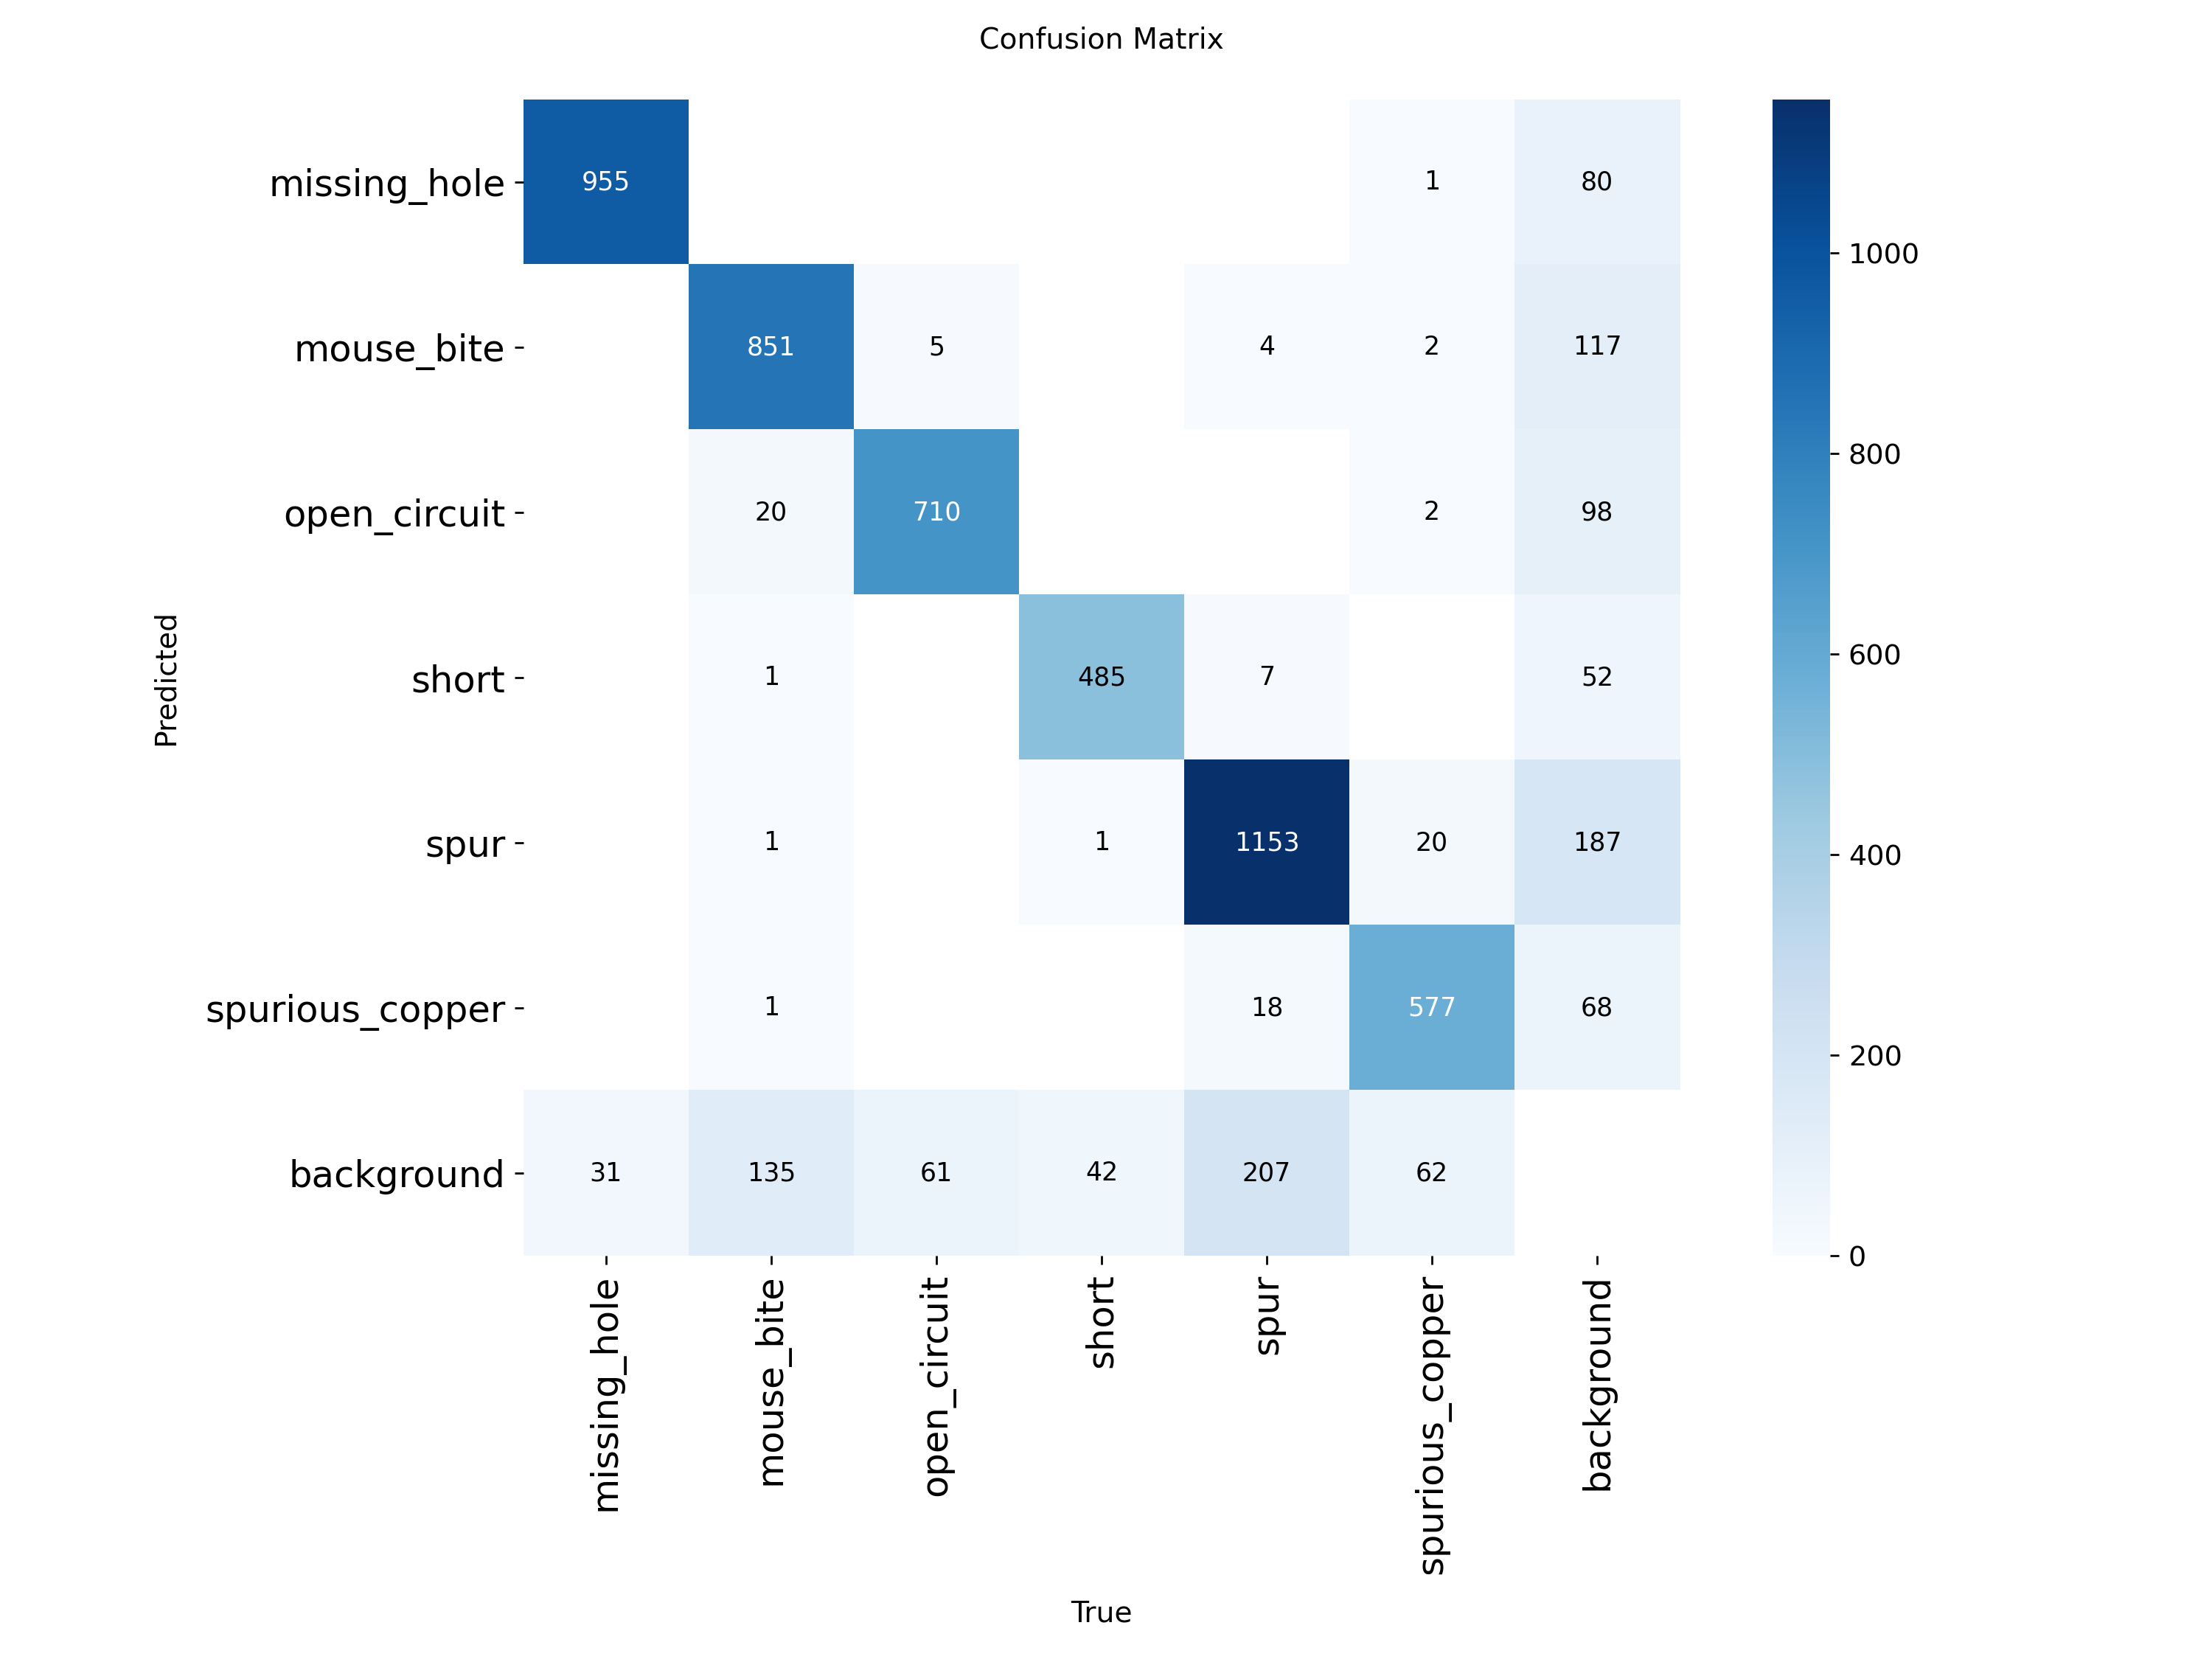

In [12]:
show_image(TEST_DIR / "confusion_matrix_normalized.png", "Normalized Confusion Matrix (Test)")
show_image(TEST_DIR / "confusion_matrix.png", "Confusion Matrix (Test)")

## 12. Predict on sample test images

In [13]:
test_images_dir = DATA_DIR / "test" / "images"

test_images = sorted([
    p for p in test_images_dir.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]
])

sample_images = random.sample(test_images, k=min(15, len(test_images)))

best_model.predict(
    source=[str(p) for p in sample_images],
    imgsz=640,
    conf=0.25,
    save=True,
    project=PROJECT,
    name=PRED_NAME,
    exist_ok=True
);


0: 640x640 1 missing_hole, 2 open_circuits, 1 short, 1 spur, 1 spurious_copper, 10.9ms
1: 640x640 1 spur, 10.9ms
2: 640x640 1 missing_hole, 1 mouse_bite, 2 open_circuits, 1 short, 1 spur, 1 spurious_copper, 10.9ms
3: 640x640 1 mouse_bite, 1 short, 1 spur, 1 spurious_copper, 10.9ms
4: 640x640 6 missing_holes, 10.9ms
5: 640x640 5 shorts, 10.9ms
6: 640x640 1 mouse_bite, 10.9ms
7: 640x640 1 missing_hole, 1 mouse_bite, 1 open_circuit, 1 short, 1 spur, 10.9ms
8: 640x640 3 spurs, 10.9ms
9: 640x640 1 spur, 10.9ms
10: 640x640 1 missing_hole, 2 mouse_bites, 1 open_circuit, 2 shorts, 3 spurs, 10.9ms
11: 640x640 2 missing_holes, 1 mouse_bite, 1 open_circuit, 2 shorts, 1 spurious_copper, 10.9ms
12: 640x640 2 missing_holes, 1 mouse_bite, 1 short, 1 spur, 1 spurious_copper, 10.9ms
13: 640x640 1 mouse_bite, 1 short, 10.9ms
14: 640x640 1 open_circuit, 3 spurs, 10.9ms
Speed: 2.3ms preprocess, 10.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/d

## 13. Display predictions

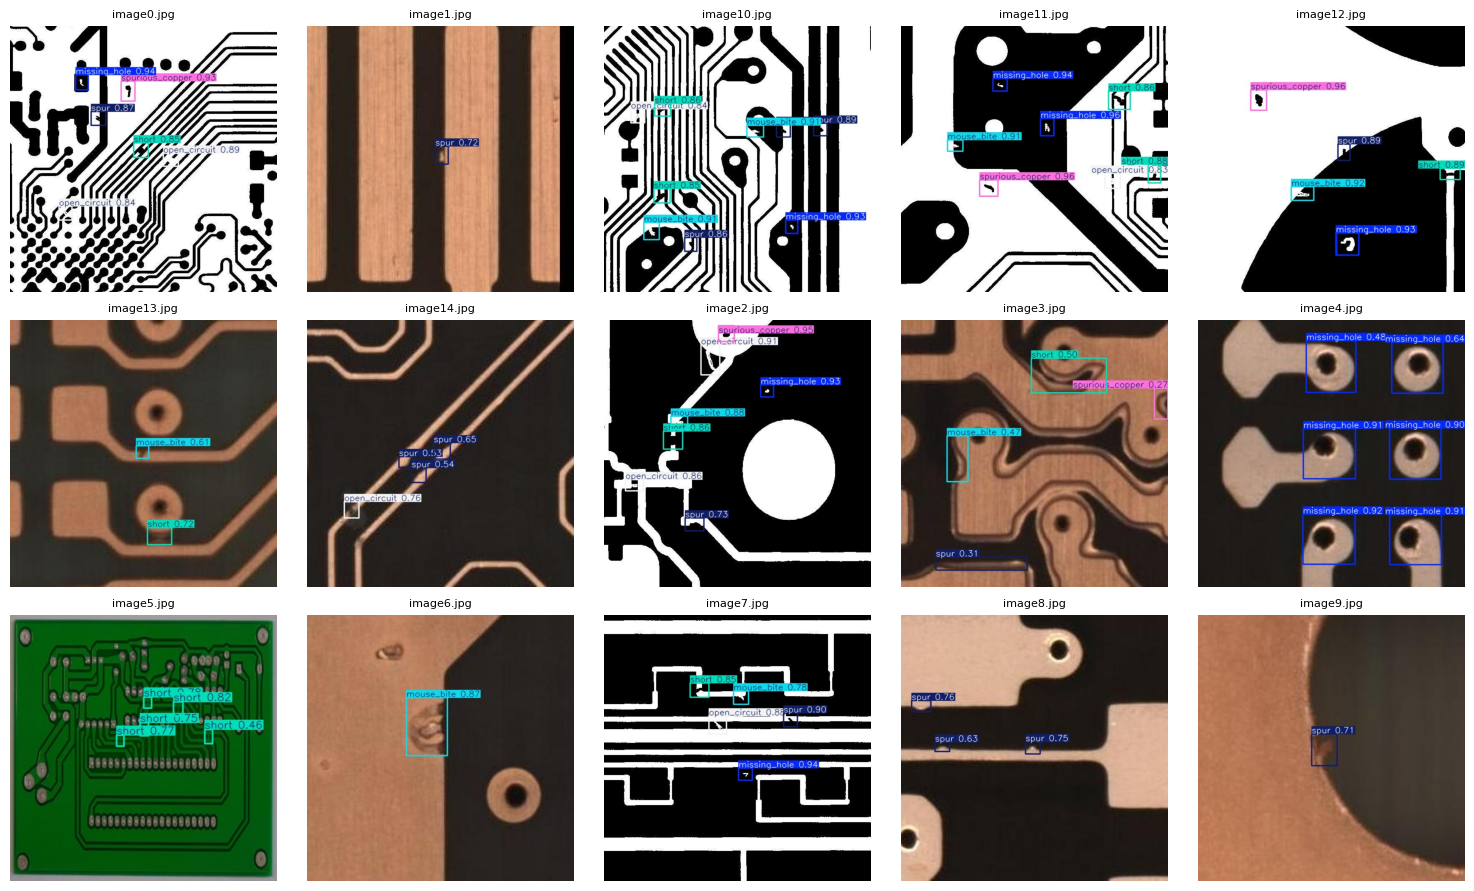

In [14]:
pred_images = sorted([
    p for p in PRED_DIR.glob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

pred_images = pred_images[:15]

rows, cols = 3, 5
plt.figure(figsize=(15, 9))

for i, img_path in enumerate(pred_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Export artifacts

In [15]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR = ARTIFACT_DIR / TRAIN_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for file_name in [
    "results.csv",
    "results.png",
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "PR_curve.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
]:
    src = TRAIN_DIR / file_name
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / file_name)

if EVAL_PT.exists():
    shutil.copy2(EVAL_PT, EXPORT_DIR / EVAL_PT.name)

for p in REPORT_DIR.glob(f"{TRAIN_NAME}*"):
    shutil.copy2(p, EXPORT_DIR / p.name)

ZIP_OUTPUT = ROOT / f"{TRAIN_NAME}_artifacts.zip"
if ZIP_OUTPUT.exists():
    ZIP_OUTPUT.unlink()

shutil.make_archive(
    base_name=str(ZIP_OUTPUT.with_suffix("")),
    format="zip",
    root_dir=str(ARTIFACT_DIR),
    base_dir=TRAIN_NAME,
)

print("Exported:", EXPORT_DIR)
print("Created zip:", ZIP_OUTPUT)
print("Size MB:", ZIP_OUTPUT.stat().st_size / (1024 * 1024))

Exported: /kaggle/working/yolov10s_artifacts/yolov10s_final_clean_6cls_e50
Created zip: /kaggle/working/yolov10s_final_clean_6cls_e50_artifacts.zip
Size MB: 15.81582260131836
